In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# ※ ①naver open API를 활용하여 네이버지식인 '전주여행'과 '경주여행'을 검색(re?) 후 백업 -> ②품사태깅할 결과 백업 -> ③명사만 추출 -> ④빈도분석(DataFrame) -> ⑤빈도 시각화(워드클라우드, Text) -> ⑥Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title+ ' ' +description(ttl_text)

In [18]:
# pip install python-dotenv # 환경변수를 쓰기 위한 라이브러리
# pip install python-decouple # 주피터 환경에서 안될 수 있음
import os
os.getcwd() # 현재 작업 디렉토리

'C:\\ai_x\\source\\07_자연어처리'

In [19]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:49               261 .env
               1개 파일                 261 바이트
               0개 디렉터리  99,952,513,024 바이트 남음


In [30]:
from dotenv import load_dotenv
load_dotenv()

client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
# print(client_id)
# print(client_secret)

In [33]:
from decouple import config
# print(config('Client_ID'))
# print(config('Client_Secret'))

In [34]:
# 네이버 개발자 센터 document에 있는 내용 그냥 그대로 가져와 봄
import os
import sys
import urllib.request
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
encText = urllib.parse.quote("경주 여행")
url = "https://openapi.naver.com/v1/search/blog?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:500])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Thu, 19 Jun 2025 11:32:05 +0900",
	"total":931092,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"<b>경주 여행<\/b>코스 루지월드 해방감을 느꼈어요",
			"link":"https:\/\/blog.naver.com\/sangil00\/223903211939",
			"description":"오랜만에 활기차고 건강하게 하루를 보낼 수 있었고요. 날씨 좋은 계절에 경주를 방문하신다면 루지월드를 꼭 <b>경주 여행<\/b>코스에 넣어보시길 바라요. 정말 후회 없는 경험이 될 거예요. #<b>경주여행<\/b>코스 #루지월드",
			"bloggername":"길을 찾는 즐거움_거칠부",
			"bloggerlink":"blog.naver.com\/sangil00",
			"postdate":"20250618"
		},
		{
			"title":"당일치기 <


In [35]:
# 패키지 import
import requests
import time
import os
import json # response 텍스트를 json 딕셔너리로
from html import unescape # description에 있는 &lt;(특수문자)을 <으로 변경, &gt;-> >
import pandas as pd
import re

In [36]:
query = "경주 여행"
start = 1
url = f"https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}"
headers = {"X-Naver-Client-Id":client_id,
           "X-Naver-Client-Secret":client_secret}
response = requests.get(url, headers=headers)
items = json.loads(response.text)['items']
print(len(items))
print(items[51],items[58])

100
{'title': '6월 <b>경주여행</b>', 'link': 'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=446801776&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8', 'description': '제가 6월달에 엄마아빠랑 언니랑 <b>경주여행</b>을 가는데요 갈곳 추천해주세요.너무 유명한 곳은 아니였음 하네요. (예... <b>경주여행</b>을 계획하시는 것 같네요. 저도 여러분들이 즐길 수 있는 장소와 활동을 추천해드릴게요. ## 1. 경주 월드컵... '} {'title': '<b>경주여행</b>(숙소추천)', 'link': 'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=460129729&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8', 'description': '안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤 <b>경주여행</b>을 갈 예정입니다 인원은 엄마3명과 초등5명 총 8명... 근데 추운 겨울 걷는건 비추입니다 ㅠㅠ 가까운 거리도 택시 타고 다니세요^^ &lt; &quot; &quot; &quot;&quot; &quot; 즐거운 <b>경주여행</b> 되시기... '}


In [37]:
item = items[58]
title = item['title']
link = item['link']
description = item['description']
print(title, link, description, sep='\n')

<b>경주여행</b>(숙소추천)
https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=460129729&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8
안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤 <b>경주여행</b>을 갈 예정입니다 인원은 엄마3명과 초등5명 총 8명... 근데 추운 겨울 걷는건 비추입니다 ㅠㅠ 가까운 거리도 택시 타고 다니세요^^ &lt; &quot; &quot; &quot;&quot; &quot; 즐거운 <b>경주여행</b> 되시기... 


In [38]:
# 위의 title의 <b>태그 없애기, description의 <b>태그 없애고 html의 특수문자 없애기
item = items[58]
title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
link = item['link']
description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
print(title, link, description, sep='\n')

 경주여행 (숙소추천)
https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=460129729&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8
안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤  경주여행 을 갈 예정입니다 인원은 엄마3명과 초등5명 총 8명... 근데 추운 겨울 걷는건 비추입니다 ㅠㅠ 가까운 거리도 택시 타고 다니세요^^ < " " "" " 즐거운  경주여행  되시기... 


In [39]:
import re
description = "#추억여행 ####ktx 타고@짱@ ㅎㅎㅎ ㅠㅠ ㅋㅋ"

# 정규표현식: 알파벳, 숫자, 한글만 남기고 나머지는 제거
description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
description = re.sub('\s+', ' ', description)
print(description)

 추억여행 ktx 타고 짱 


In [40]:
# 네이버 API 계정 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
queries = ['전주 여행', '경주 여행']
max_start = 5

In [41]:
# 방법1
def get_search_element_save(query, start):
    headers = {'X-Naver-Client-Id':client_id,
           'X-Naver-Client-Secret':client_secret}
    url = f'https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}'
    response = requests.get(url, headers=headers)
    items = json.loads(response.text)['items']
    for i, item in enumerate(items):
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
#         print('수정전 :', description)
        description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description)
#         print('수정후 :', description)
        # print(query, (start*100+i+1), title, link, description, title+' ' +description)
        with open(file_name, 'a', encoding='utf-8') as file:
            file.write('{}\t{}\t{}\t{}\t{}\t{}\n'.format(query, 
                                                         (start-1)*100+i+1,
                                                         title,
                                                         link,
                                                         description, 
                                                         title + ' ' +description))

In [42]:
# 데이터를 저장할 파일 생성 (naver_kin.txt)하고 title 저장(header저장)
file_name = 'data/naver_kin.csv'
with open(file_name, 'w', encoding='utf-8') as file:
    file.write('{}\t{}\t{}\t{}\t{}\t{}\n'.format('query', 
                            'no','title','link', 'description', 'total_text'))

In [ ]:
for query in queries:
    for start in range(1, max_start+1):
        print(start, query, '읽는 중')
        get_search_element_save(query, start)
        time.sleep(0.5)

# ①naver open API를 활용하여 네이버지식인 '전주여행'과 '경주여행'을 검색(re?) 후 백업

In [166]:
# 함수 작성
def get_srch_el_rtn_naver_kin(keyword, start):
    from dotenv import load_dotenv
    import os
    import requests
    import json
    import pandas as pd
    
    load_dotenv()
    client_id = os.getenv('Client_ID')
    client_secret = os.getenv('Client_Secret')

    headers = {'X-Naver-Client-Id':client_id,
              'X-Naver-Client-Secret':client_secret}
    url = f'https://openapi.naver.com/v1/search/kin.json?query={keyword}&display=100&start={start}'
    response = requests.get(url, headers=headers)
    items = json.loads(response.text)['items'] # json

    items_list = []
    for idx, item in enumerate(items):
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
        description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description) # 빈스트링 한개로

        items_list.append({
            'keyword':keyword,
            'no':(start-1)*100+idx+1,
            'title':item.get('title').replace('<b>','').replace('</b>',''), # item['title']
            'link':item.get('link'),
            'description':description,
            'ttl_text':title+ ' ' + description
        })
    return items_list

In [168]:
queries = ['경주 여행', '전주 여행']
max_start = 5
for query in queries:
    result_total = []
    for start in range(1, max_start+1):
        print(start, query, '읽는 중')
        result_total.extend(get_srch_el_rtn_naver_kin(query, start))
        time.sleep(0.5)
    df = pd.DataFrame(result_total)
    df.to_csv(f'data/naver_kin_{query}.csv', index=False, sep='\t')

1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중
5 경주 여행 읽는 중
1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
5 전주 여행 읽는 중


# 2. 품사 태깅 저장

In [74]:
import pandas as pd
df = pd.DataFrame([])
for idx, query in enumerate(queries):
    df = pd.concat([df, pd.read_csv(f'data/naver_kin_{query}.csv', sep='\t')], ignore_index=True)
df.tail(2)

,keyword,no,title,link,description,ttl_text
998,경주 여행,499,2박 경주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가보는곳이라 첫날은 황남관...,경주여행 (숙소추천) 11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가...
999,경주 여행,500,경주 여행지 추천,https://kin.naver.com/qna/detail.naver?d1id=9&...,2 부산을 벗어난 경주 여행 지 알려주세요 3 당일치기로 경주 여행 코스 밑에 자...,경주여행 (숙소추천) 2 부산을 벗어난 경주 여행 지 알려주세요 3 당일치기로 ...


In [76]:
df_list = df[['keyword','no','ttl_text']].values.tolist()
df_list[::500]

[['전주 여행',
  1,
  ' 경주여행 (숙소추천)  추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전북투어패스 통합이용권 전북핫플 여러여행지 다양한체험 카페이용추가 전주여행 필수 편안하고 즐거운 날이 되시길 바라겠습니다 감사합니다 '],
 ['경주 여행',
  1,
  ' 경주여행 (숙소추천) 추석에 경주 여행 가는거 어떻게 생각하시나요 서울에서 버스를 타고 갈 경우 버스가 버스전용 차선에서 운행하나요 질문하신 추석 경주여행 관련 답변 드리도록 하겠습니다 첨성대 석굴암 불국사 등 유적지는 연중무휴로 ']]

In [77]:
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
stopwords = ['전주','경주','여행']
select_pos = ['NNG', 'NNP'] 

In [79]:
postagged_list = []
for idx, row in enumerate(df_list):
    keyword = row[0]
    no = row[1]
    text = row[2]
    text_pos = analyzer.pos(text)
    # analyzer가 MeCab이 아닐 경우 시간이 좀 걸려서 250개마다 로그 출력
    if idx%2500==0:
        print("{}의 {}번째 품사태깅 결과 {}개 저장중".format(keyword, 
                                                no, 
                                                len(text_pos), end='\n\n'))
    for token, pos in text_pos:
        # if token not in stopwords and pos in select_pos: 라고 하면 명사만 추출
        if token not in stopwords and len(token)>1: # 모든 품사를 우선 다 넣고 나중에 빼려면
            postagged_list.append({'keyword':keyword,
                                 'no':no,
                                 'token':token,
                                 'pos':pos})
df_postagged = pd.DataFrame(postagged_list)
df_postagged

전주 여행의 1번째 품사태깅 결과 57개 저장중


,keyword,no,token,pos
0,전주 여행,1,숙소,NNG
1,전주 여행,1,추천,NNG
2,전주 여행,1,추억,NNG
3,전주 여행,1,7080,SN
4,전주 여행,1,다양,NNG
...,...,...,...,...
23974,경주 여행,500,참고,NNG
23975,경주 여행,500,쭈니,NNP
23976,경주 여행,500,아빠,NNG
23977,경주 여행,500,블로그,NNG


In [80]:
df_postagged.to_csv('data/naver_kin_pos.csv', index=False, sep='\t')

# 3. 명사만 추출

In [81]:
df_postagged = pd.read_csv('data/naver_kin_pos.csv', sep='\t')

In [82]:
df_nouns = df_postagged.loc[df_postagged['pos'].isin(['NNP', 'NNG']),
                            ['keyword', 'token','pos']]
df_nouns.head()

,keyword,token,pos
0,전주 여행,숙소,NNG
1,전주 여행,추천,NNG
2,전주 여행,추억,NNG
4,전주 여행,다양,NNG
5,전주 여행,체험,NNG


In [83]:
df_nouns.to_csv('data/naver_kin_pos_nouns.csv', index=False, sep='\t')

# 4.빈도분석(DataFrame) 후 백업

In [85]:
df_nouns = pd.read_csv('data/naver_kin_pos_nouns.csv', sep='\t')
df_nouns.shape

(14622, 3)

In [86]:
df_nouns.iloc[::5000]

,keyword,token,pos
0,전주 여행,숙소,NNG
5000,전주 여행,주달,NNG
10000,경주 여행,독채,NNG


In [87]:
df_nouns.groupby(['keyword','token'], as_index=False)['pos'].count()

,keyword,token,pos
0,경주 여행,가격,10
1,경주 여행,가능,24
2,경주 여행,가본적,5
3,경주 여행,가성,5
4,경주 여행,가시,5
...,...,...,...
860,전주 여행,호텔,22
861,전주 여행,확인,5
862,전주 여행,환급,5
863,전주 여행,회관,5


In [92]:
df_token_grp = df_nouns.groupby('keyword')['token'].value_counts()
df_token_grp

keyword  token
경주 여행    추천       765
         숙소       609
         코스       312
         계획       146
         답변       106
                 ... 
전주 여행    카페이        1
         통합         1
         패스         1
         편안         1
         필수         1
Name: token, Length: 865, dtype: int64

In [93]:
df_token_grp = df_token_grp.reset_index(name='token_count')
df_token_grp.tail()

,keyword,token,token_count
860,전주 여행,카페이,1
861,전주 여행,통합,1
862,전주 여행,패스,1
863,전주 여행,편안,1
864,전주 여행,필수,1


In [98]:
# 전주 여행과 경주 여행의 여행 빈도 추출
import numpy as np
from IPython.display import display

a = pd.DataFrame([['단어1', 90],
                 ['단어2',80]], columns=['단어','경주빈도'])
b = pd.DataFrame([['단어1', 99],
                 ['단어3',81]], columns=['단어','전주빈도'])
display(a)
display(b)
ab = pd.merge(a, b, 
         how='outer', # inner(공통), left, right, outer
         on='단어')   # 두 프레임을 어떤 열 기준으로 합칠지 지정
#pd.concat([a, b], axis=1)
ab.fillna(0, inplace=True)
ab['경주빈도'] = ab['경주빈도'].astype(np.int16)
ab['전주빈도'] = ab['전주빈도'].astype('int')
display(ab)
ab.info()

,단어,경주빈도
0,단어1,90
1,단어2,80


,단어,전주빈도
0,단어1,99
1,단어3,81


,단어,경주빈도,전주빈도
0,단어1,90,99
1,단어2,80,0
2,단어3,0,81


<class 'pandas.core.frame.DataFrame'>
Int64Index: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   단어      3 non-null      object
 1   경주빈도    3 non-null      int16 
 2   전주빈도    3 non-null      int32 
dtypes: int16(1), int32(1), object(1)
memory usage: 66.0+ bytes


In [99]:
df_kj = df_token_grp.loc[df_token_grp['keyword']=='경주 여행', ['token','token_count']]
df_jj = df_token_grp.loc[df_token_grp['keyword']=='전주 여행', ['token','token_count']]
df_kj.shape, df_jj.shape

((457, 2), (408, 2))

In [100]:
df_kj.head()

,token,token_count
0,추천,765
1,숙소,609
2,코스,312
3,계획,146
4,답변,106


In [101]:
df_jj.head()

,token,token_count
457,추천,710
458,숙소,555
459,여수,349
460,코스,326
461,주달,304


In [102]:
df_mrg = pd.merge(df_kj, df_jj, how='outer', on='token')
print(df_mrg.shape)
df_mrg

(703, 3)


,token,token_count_x,token_count_y
0,추천,765.0,710.0
1,숙소,609.0,555.0
2,코스,312.0,326.0
3,계획,146.0,61.0
4,답변,106.0,55.0
...,...,...,...
698,유익,NaN,1.0
699,찜질방,NaN,1.0
700,카페이,NaN,1.0
701,통합,NaN,1.0


In [103]:
df_mrg.columns = ['token','경주빈도','전주빈도']
df_mrg.fillna(0, inplace=True)
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype('int')
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int64) # 'int64'
df_mrg

,token,경주빈도,전주빈도
0,추천,765,710
1,숙소,609,555
2,코스,312,326
3,계획,146,61
4,답변,106,55
...,...,...,...
698,유익,0,1
699,찜질방,0,1
700,카페이,0,1
701,통합,0,1


In [104]:
df_mrg['빈도합'] = df_mrg['경주빈도'] + df_mrg['전주빈도']
df_mrg['전주비율'] = df_mrg['전주빈도'] / df_mrg['빈도합']
df_mrg['경주비율'] = df_mrg['경주빈도'] / df_mrg['빈도합']
df_mrg.head(10)

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,추천,765,710,1475,0.481356,0.518644
1,숙소,609,555,1164,0.476804,0.523196
2,코스,312,326,638,0.510972,0.489028
3,계획,146,61,207,0.294686,0.705314
4,답변,106,55,161,0.341615,0.658385
5,일정,96,70,166,0.421687,0.578313
6,맛집,95,282,377,0.748011,0.251989
7,황리,90,0,90,0.000000,1.000000
8,가족,85,15,100,0.150000,0.850000
9,질문,80,45,125,0.360000,0.640000


In [105]:
df_mrg_srt = df_mrg.sort_values(by=['빈도합'], ascending=False)
df_mrg_srt

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,추천,765,710,1475,0.481356,0.518644
1,숙소,609,555,1164,0.476804,0.523196
2,코스,312,326,638,0.510972,0.489028
6,맛집,95,282,377,0.748011,0.251989
457,여수,0,349,349,1.000000,0.000000
...,...,...,...,...,...,...
455,전용,1,0,1,0.000000,1.000000
451,권역,1,0,1,0.000000,1.000000
452,연중무휴,1,0,1,0.000000,1.000000
453,운행,1,0,1,0.000000,1.000000


In [106]:
df_mrg_srt['전주비율'] = df_mrg_srt['전주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg_srt['경주비율'] = df_mrg_srt['경주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg_srt

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,추천,765,710,1475,48.14%,51.86%
1,숙소,609,555,1164,47.68%,52.32%
2,코스,312,326,638,51.10%,48.90%
6,맛집,95,282,377,74.80%,25.20%
457,여수,0,349,349,100.00%,0.00%
...,...,...,...,...,...,...
455,전용,1,0,1,0.00%,100.00%
451,권역,1,0,1,0.00%,100.00%
452,연중무휴,1,0,1,0.00%,100.00%
453,운행,1,0,1,0.00%,100.00%


In [107]:
df_mrg_srt.reset_index(drop=True, inplace=True)
df_mrg_srt

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,추천,765,710,1475,48.14%,51.86%
1,숙소,609,555,1164,47.68%,52.32%
2,코스,312,326,638,51.10%,48.90%
3,맛집,95,282,377,74.80%,25.20%
4,여수,0,349,349,100.00%,0.00%
...,...,...,...,...,...,...
698,전용,1,0,1,0.00%,100.00%
699,권역,1,0,1,0.00%,100.00%
700,연중무휴,1,0,1,0.00%,100.00%
701,운행,1,0,1,0.00%,100.00%


In [108]:
df_mrg_srt.to_csv('data/naver_kin_pos_nouns_count.txt', sep='\t')

# 5. 빈도 시각화(워드클라우드, Text)

In [109]:
df_nouns = pd.read_csv('data/naver_kin_pos_nouns.csv', sep='\t')
print(df_nouns.shape)
df_nouns.iloc[::3000]

(14622, 3)


,keyword,token,pos
0,전주 여행,숙소,NNG
3000,전주 여행,팔복,NNG
6000,전주 여행,주달,NNG
9000,경주 여행,개화,NNG
12000,경주 여행,불국사,NNG


In [110]:
df_nouns['pos'].unique()

array(['NNG', 'NNP'], dtype=object)

In [141]:
df_kj_noun = df_nouns.loc[df_nouns['keyword']=='경주 여행','token'].to_list()
df_jj_noun = df_nouns.loc[df_nouns['keyword']=='전주 여행','token'].to_list()
df_kjj_noun = df_nouns.loc[(df_nouns['keyword']=='전주 여행') | (df_nouns['keyword']=='경주 여행'),'token'].to_list()
print(df_kj_noun[:5])
print(df_jj_noun[:5])
kj = ' '.join(df_kj_noun)
jj = ' '.join(df_jj_noun)
kjj = ' '.join(df_kjj_noun)
print(kj[:10])
print(jj[:10])
len(df_kj_noun), len(df_jj_noun)

['숙소', '추천', '추석', '생각', '서울']
['숙소', '추천', '추억', '다양', '체험']
숙소 추천 추석 생
숙소 추천 추억 다


(6855, 7767)

In [113]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
color_map = "Blues"
font_path = 'data/NanumPenScript-Regular.ttf'

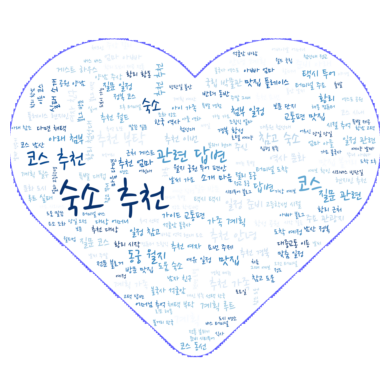

In [114]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/heart.jpg'))
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap=color_map,
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=777,
    font_path = font_path,
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
).generate(kj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [115]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/naver_kin_경주.jpg')

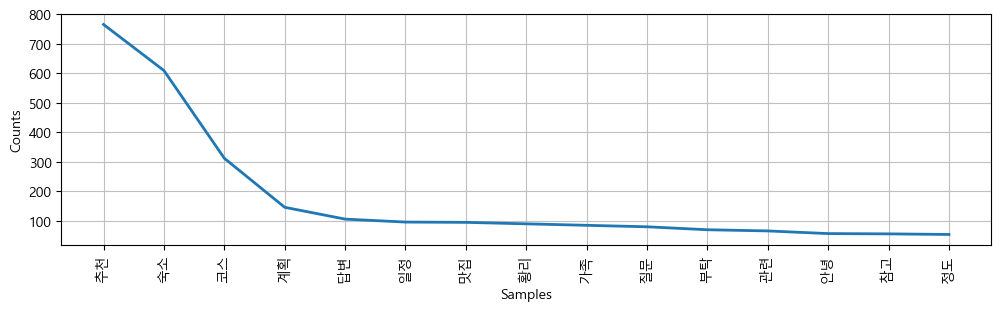

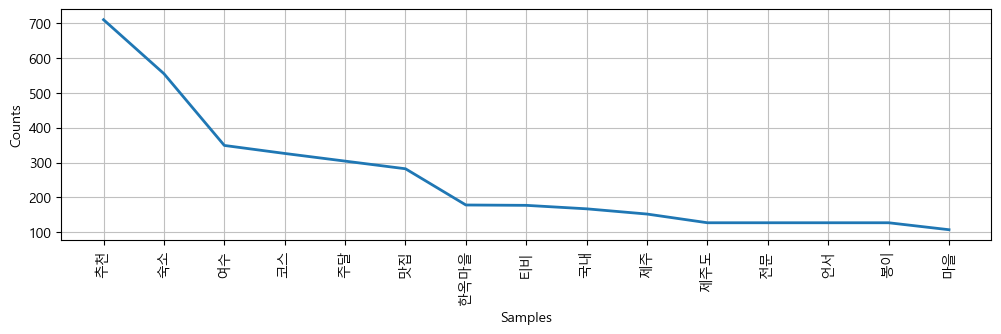

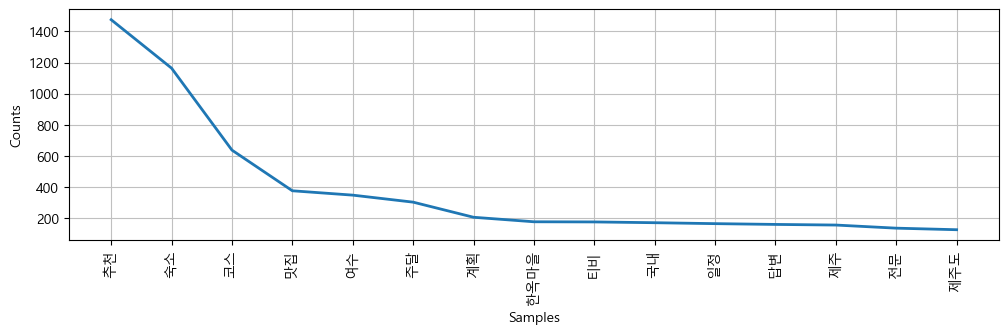

In [143]:
data_text_k = nltk.Text(df_kj_noun)
data_text_j = nltk.Text(df_jj_noun)
data_text_kjj = nltk.Text(df_kjj_noun)
plt.figure(figsize=(12, 3))
plt.rc('font', family='Malgun Gothic')
data_text_k.plot(15)
plt.figure(figsize=(12, 3))
data_text_j.plot(15)
plt.figure(figsize=(12, 3))
data_text_kjj.plot(15)
plt.show()

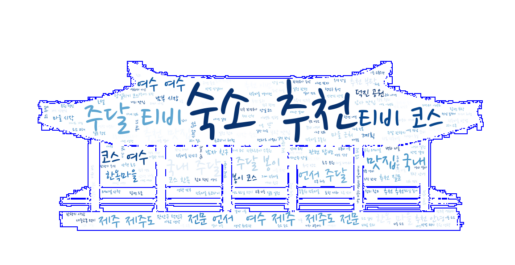

In [116]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/korea-house-black-fill.png'))
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap=color_map,
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=100,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=777,
    font_path = font_path,
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
).generate(jj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

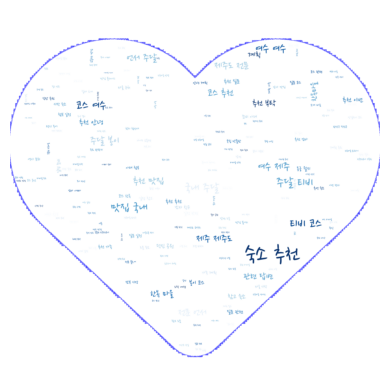

In [145]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/heart.jpg'))
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap=color_map,
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=100,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=777,
    font_path = font_path,
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
).generate(kjj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/naver_kin_전주.jpg')

# 6. Word2Vec

In [165]:
import pandas as pd

df = pd.DataFrame([])
for idx, query in enumerate(queries):
    df = pd.concat([df, pd.read_csv(f'data/naver_kin_{query}.csv', sep='\t')], ignore_index=True)
df.sample()

,keyword,no,title,link,description,ttl_text
0,전주 여행,1,전주 가볼만한곳 추천 받아요,https://kin.naver.com/qna/detail.naver?d1id=9&...,추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전...,경주여행 (숙소추천) 추억의 7080 다양한체험 7080감성 추억여행 테마박물관...


In [153]:
total_text_list = df['ttl_text'].to_list()
total_text_list[-2:]

[' 경주여행 (숙소추천) 11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가보는곳이라 첫날은 황남관한옥호텔 에서 1박하고 이튿날은 청공한옥스테이에서 1박 총 2박3일 계획인데요 여행스케쥴을 어떻게 ',
 ' 경주여행 (숙소추천)  2 부산을 벗어난 경주 여행 지 알려주세요 3 당일치기로 경주 여행 코스 밑에 자세하게 권역별로 여행코스를 소개했습니다 경주여행 이 처음이라면 대릉원 첨성대 참고로 쭈니아빠 블로그를 방문하시면 경주여행 ']

In [154]:
select_pos = ['NNP', 'NNG'] # Komoran, Kkma, MeCab의 일반명사, 고유명사
# select_pos = ['Noun'] # Okt의 일반명사, 고유명사
# select_pos = ['NC', 'NQ']# Hannanum의 보통명사, 고유명사
불용어 = {'여행'}

In [155]:
%%time
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [token for token, tag in analyzer.pos(total_text) 
                     if tag in select_pos and 
                             len(token)>1 and
                             token not in 불용어] # 명사, 2글자이상, 불용어제외
    total_noun_list.append(noun_list)

CPU times: total: 859 ms
Wall time: 842 ms


In [156]:
print(total_noun_list[-2:])

[['경주', '숙소', '추천', '중순', '남편', '경주', '계획', '첫날', '황남', '호텔', '이튿날', '청공', '옥스', '테이', '계획'], ['경주', '숙소', '추천', '부산', '경주', '당일', '경주', '코스', '권역', '코스', '소개', '경주', '처음', '대릉원', '첨성대', '참고', '쭈니', '아빠', '블로그', '방문', '경주']]


In [157]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list, window=10, min_count=2, workers=-1, 
                 sg=1) # 소량데이터에 더 잘 맞음

In [158]:
model.wv.most_similar('전주')

[('난장', 0.3641005754470825),
 ('조정', 0.21867415308952332),
 ('시즌', 0.21632219851016998),
 ('아침', 0.2159893959760666),
 ('경기전', 0.21469099819660187),
 ('관심', 0.2134207934141159),
 ('참조', 0.20914912223815918),
 ('식비', 0.20906010270118713),
 ('가실', 0.2070489227771759),
 ('오릉', 0.20607852935791016)]

In [159]:
model.wv.most_similar('경주')

[('교통수단', 0.3595535457134247),
 ('체험', 0.2897421419620514),
 ('필요', 0.275379478931427),
 ('요번', 0.2731468081474304),
 ('부분', 0.2580290138721466),
 ('아들', 0.2295033037662506),
 ('블로그', 0.22023281455039978),
 ('제주도', 0.21883943676948547),
 ('한옥마을', 0.21617142856121063),
 ('평점', 0.2135322391986847)]

In [160]:
print('2번이상 나와서 학습된 단어들 : ',list(model.wv.index_to_key[:10]))
print(len(model.wv))

2번이상 나와서 학습된 단어들 :  ['경주', '전주', '추천', '숙소', '코스', '맛집', '여수', '주달', '계획', '한옥마을']
693


In [161]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{} 단어가 훈련 데이터에 없음".format(key))

입력된 단어와 유사한 단어 10개를 출력합니다.
추천
추천와 유사한 단어:
[('남자', 0.3698463439941406), ('보리암', 0.2762660086154938), ('봄바람', 0.2533281147480011), ('인당', 0.24960343539714813), ('목대', 0.24882428348064423), ('도로공사', 0.2285403162240982), ('서신동', 0.2213573008775711), ('아래', 0.21197080612182617), ('입장료', 0.21178807318210602), ('접근성', 0.20583979785442352)]


In [133]:
# pip install gensim
from gensim.models import Word2Vec
model_k = Word2Vec([df_kj_noun], # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1 # 병렬처리 core수. -1: 모든 가용 코어 사용
                )
model_k

In [135]:
model_k.wv.most_similar('추천', topn=20)

[('밀면', 0.3595535457134247),
 ('대릉원', 0.2897421419620514),
 ('전문', 0.275379478931427),
 ('접근성', 0.2731468081474304),
 ('신라', 0.2295033037662506),
 ('검색', 0.22023281455039978),
 ('엄마', 0.21883943676948547),
 ('질문', 0.21617142856121063),
 ('운영', 0.20657561719417572),
 ('개화', 0.20463387668132782),
 ('교통편', 0.20441339910030365),
 ('옥스', 0.2037125676870346),
 ('인기', 0.19987967610359192),
 ('시즌', 0.19577839970588684),
 ('동궁', 0.19543619453907013),
 ('독채', 0.1952831894159317),
 ('제공', 0.18593086302280426),
 ('자신', 0.18578827381134033),
 ('안내소', 0.1856287270784378),
 ('내년', 0.18269363045692444)]

In [136]:
from gensim.models import Word2Vec
model_j = Word2Vec([df_jj_noun], # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1 # 병렬처리 core수. -1: 모든 가용 코어 사용
                )
model_j

In [137]:
model_j.wv.most_similar('추천', topn=20)

[('내공', 0.3595535457134247),
 ('음식', 0.2897421419620514),
 ('세일', 0.275379478931427),
 ('체증', 0.2731468081474304),
 ('다음', 0.2295033037662506),
 ('국립', 0.22023281455039978),
 ('일정', 0.21883943676948547),
 ('제주', 0.21617142856121063),
 ('전주국', 0.20657561719417572),
 ('가운데', 0.20463387668132782),
 ('관련', 0.20441339910030365),
 ('중식', 0.19577839970588684),
 ('시간', 0.19543619453907013),
 ('여행지', 0.18593086302280426),
 ('중순', 0.18578827381134033),
 ('법률', 0.1856287270784378),
 ('결정', 0.18081441521644592),
 ('주목적', 0.17482143640518188),
 ('가격', 0.17216654121875763),
 ('중심', 0.17090022563934326)]

In [139]:
from gensim.models import Word2Vec
model_kjj = Word2Vec([df_kjj_noun], # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1 # 병렬처리 core수. -1: 모든 가용 코어 사용
                )
model_kjj

In [140]:
model_kjj.wv.most_similar('추천', topn=20)

[('조정', 0.3595535457134247),
 ('대중교통', 0.2897421419620514),
 ('예상', 0.275379478931427),
 ('부족', 0.2731468081474304),
 ('도로공사', 0.2580290138721466),
 ('남부', 0.2295033037662506),
 ('블로그', 0.22023281455039978),
 ('봉이', 0.21883943676948547),
 ('국내', 0.21617142856121063),
 ('부분', 0.2135322391986847),
 ('교통', 0.20657561719417572),
 ('식비', 0.20463387668132782),
 ('식당', 0.20441339910030365),
 ('가본적', 0.2037125676870346),
 ('주이', 0.19987967610359192),
 ('페스타', 0.19577839970588684),
 ('이번', 0.19543619453907013),
 ('사회', 0.1952831894159317),
 ('제가', 0.19412167370319366),
 ('요금', 0.19114740192890167)]

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


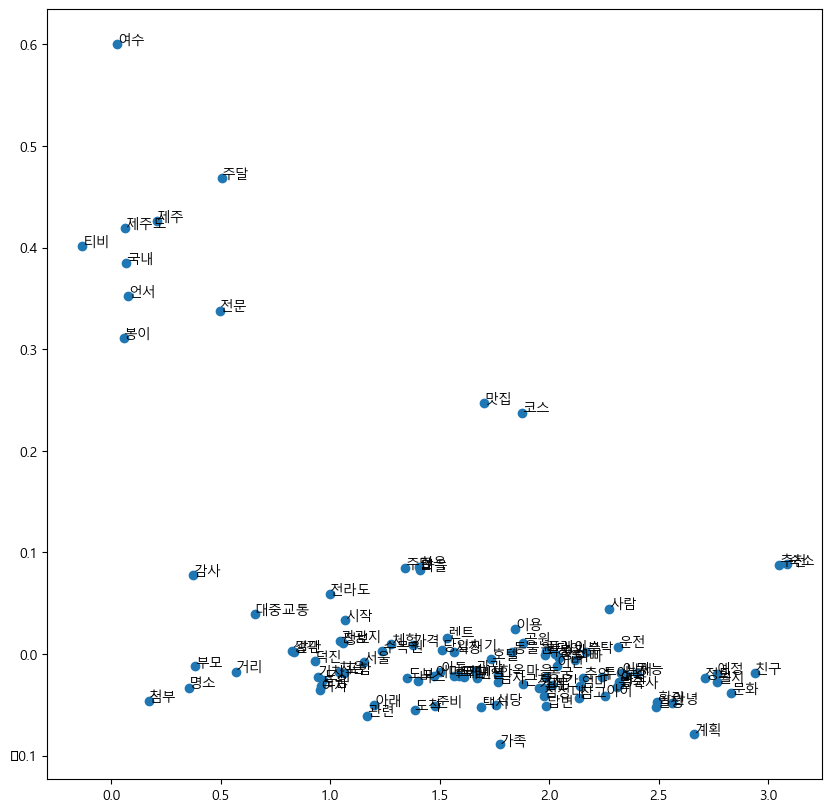

In [151]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# train model
model = Word2Vec([df_kjj_noun], min_count=1)

# fit a 2d PCA model to the vectors
X = model.wv.vectors  # 단어 벡터 행렬 (단어 개수 x 벡터 차원)

# apply PCA
pca = PCA(n_components=2)        # 2차원 주성분 분석 실시
result = pca.fit_transform(X)    # X좌표와 Y좌표 저장


# create a scatter plot of the projection
n_points =100 # 뿌릴갯수
plt.figure(figsize=(10, 10))               # 그림 크기
plt.scatter(result[:n_points, 0], result[:n_points, 1])    # X좌표, Y좌표를 이용해 산점도 그리기
words = model.wv.index_to_key  # 단어 리스트
for i, word in enumerate(words[:n_points]):           # 레이블을 위치(key)와 레이블(vlaue)로 분리
  plt.annotate(word, (result[i, 0], result[i, 1]))  # X좌표와 Y좌표에 맞게 레이블 붙이기
plt.show()

In [ ]:
from nltk.tokenize import RegexpTokenizer
from nltk.tag      import pos_tag
ret = RegexpTokenizer('[가-힣]{2,}') # '[\w]'
title_Des_jj = [ for i in range(len(df_jj['ttl_text']))]
title_Des_kj = [ for i in range(len(df_kj['ttl_text']))]

from konlpy.tag import Kkma
kkma = Kkma()
j_kins = []
k_kins = []
for i in range(display):
    jnoun_list = kkma.nouns(title_Des_jj[i])
    knoun_list = kkma.nouns(title_Des_kj[i])
    불용어 = {'여행', '경주', '전주'}
    jnoun_list = [word for word in jnoun_list if word not in 불용어]
    knoun_list = [word for word in knoun_list if word not in 불용어]
    j_kins.append(' '.join(jnoun_list))
    k_kins.append(' '.join(knoun_list))

jj_nouns = ret.tokenize(' '.join(j_kins))
kj_nouns = ret.tokenize(' '.join(k_kins))

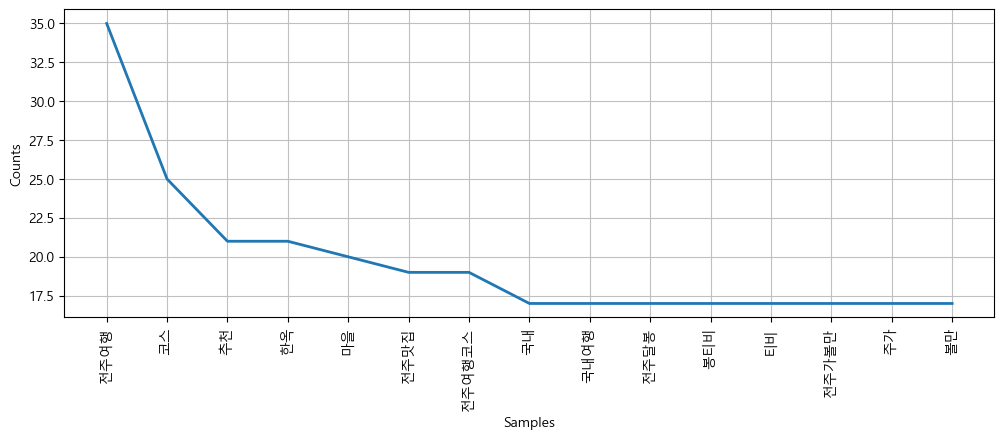

In [4]:
import nltk
from matplotlib import pyplot as plt
data_text_j = nltk.Text(jj_nouns)
plt.figure(figsize=(12, 4))
plt.rc('font', family='Malgun Gothic')
data_text_j.plot(15)
plt.show()

In [5]:
data_text_j.vocab().most_common(20)

[('전주여행', 35),
 ('코스', 25),
 ('추천', 21),
 ('한옥', 21),
 ('마을', 20),
 ('전주맛집', 19),
 ('전주여행코스', 19),
 ('국내', 17),
 ('국내여행', 17),
 ('전주달봉', 17),
 ('봉티비', 17),
 ('티비', 17),
 ('전주가볼만', 17),
 ('주가', 17),
 ('볼만', 17),
 ('한옥마을', 16),
 ('여수', 16),
 ('여수여행', 16),
 ('제주', 15),
 ('제주도', 15)]

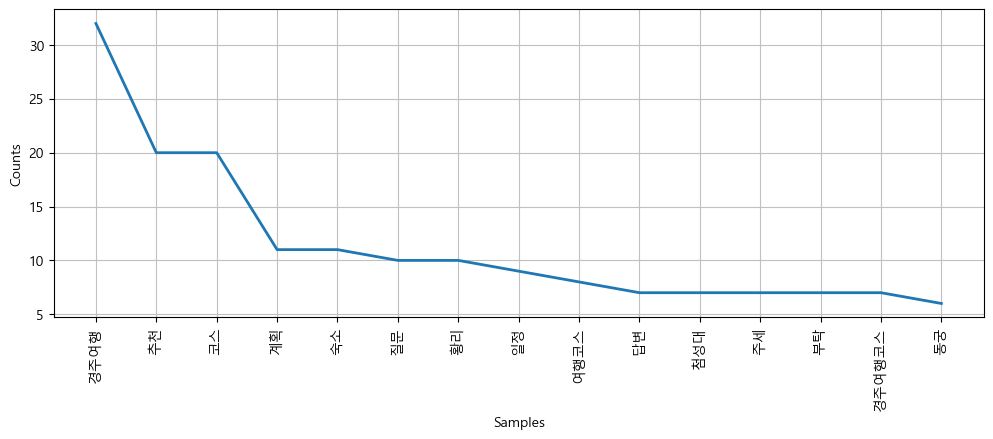

In [7]:
data_text_k = nltk.Text(kj_nouns)
plt.figure(figsize=(12, 4))
plt.rc('font', family='Malgun Gothic')
data_text_k.plot(15)
plt.show()

In [8]:
data_text_k.vocab().most_common(20)

[('경주여행', 32),
 ('추천', 20),
 ('코스', 20),
 ('계획', 11),
 ('숙소', 11),
 ('질문', 10),
 ('황리', 10),
 ('일정', 9),
 ('여행코스', 8),
 ('답변', 7),
 ('첨성대', 7),
 ('주세', 7),
 ('부탁', 7),
 ('경주여행코스', 7),
 ('동궁', 6),
 ('일차', 6),
 ('월지', 6),
 ('관련', 5),
 ('맛집', 5),
 ('근처', 5)]

<function matplotlib.pyplot.show(close=None, block=None)>

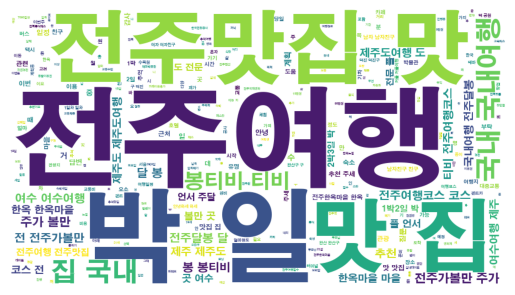

In [9]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordCl = WordCloud(
                font_path='C:/Windows/Fonts/H2GTRE.TTF',
                width=900, # 생성될 이미지 가로길이
                height=500,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.5,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
)
wordCl.generate(' '.join(j_kins))
plt.imshow(wordCl)
plt.axis('off')
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

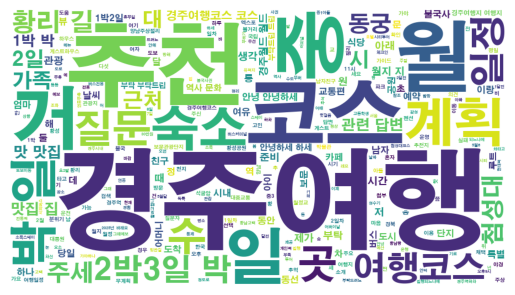

In [10]:
wordCl.generate(' '.join(k_kins))
plt.imshow(wordCl)
plt.axis('off')
plt.show

In [11]:
# pip install gensim
from gensim.models import Word2Vec
model_j = Word2Vec(title_Des_jj, # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1 # 병렬처리 core수. -1: 모든 가용 코어 사용
                )
model_j

In [25]:
model_j.wv.most_similar('맛', topn=10)

[('며', 0.3504181504249573),
 ('차', 0.2690090537071228),
 ('-', 0.24812303483486176),
 ('제', 0.22873304784297943),
 (']', 0.2176259160041809),
 ('착', 0.20557276904582977),
 ('편', 0.20196840167045593),
 ('학', 0.20141147077083588),
 ('님', 0.19172391295433044),
 ('외', 0.189864382147789)]

In [23]:
model_k = Word2Vec(title_Des_kj, # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1 # 병렬처리 core수. -1: 모든 가용 코어 사용
                )
model_k

In [24]:
model_j.wv.most_similar('맛', topn=10)

[('며', 0.3504181504249573),
 ('차', 0.2690090537071228),
 ('-', 0.24812303483486176),
 ('제', 0.22873304784297943),
 (']', 0.2176259160041809),
 ('착', 0.20557276904582977),
 ('편', 0.20196840167045593),
 ('학', 0.20141147077083588),
 ('님', 0.19172391295433044),
 ('외', 0.189864382147789)]